# Orbits of Known Objects

galpy can look up the phase-space coordinates of known astronomical objects
by name, using SIMBAD or built-in catalogs. This makes it easy to compute
orbits for stars, clusters, galaxies, and solar system bodies.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Looking up a single object

`Orbit.from_name` looks up built-in catalogs or, if this fails, queries SIMBAD if
`astroquery` is installed, to get the phase-space coordinates of a named object.
`Orbit.from_name` supports **tab completion** in IPython/Jupyter for the list of
built-in objects (globular clusters, dwarf satellite galaxies, etc.).

<div class="alert alert-warning">

**Warning**

Orbits initialized using `Orbit.from_name` have physical output
*turned on by default*, so methods will return outputs in physical units unless
you call `o.turn_physical_off()`.

</div>

In [2]:
o = Orbit.from_name("NGC104")  # 47 Tuc
print(o)
print("RA =", o.ra(), "deg")
print("Dec =", o.dec(), "deg")

RA = 6.024000000000262 deg
Dec = -72.08100000000005 deg


## Globular clusters

Many well-known globular clusters are in the built-in catalog.

In [3]:
o_oc = Orbit.from_name("Omega Cen")
print("Omega Cen R =", o_oc.R(), "kpc")
print("Omega Cen z =", o_oc.z(), "kpc")

Omega Cen R = 6.20868822084256 kpc
Omega Cen z = 1.4146321192354743 kpc


Note that you can also get Omega Cen by its NGC number:

In [4]:
o_oc = Orbit.from_name("NGC 5139")  # Omega Centauri
print("Omega Cen R =", o_oc.R(), "kpc")
print("Omega Cen z =", o_oc.z(), "kpc")

Omega Cen R = 6.20868822084256 kpc
Omega Cen z = 1.4146321192354743 kpc


Specifying the name like this uses the built-in catalog, which is more reliable than SIMBAD for globular clusters, so it's recommended to use the built-in name when possible. However, if you want to use SIMBAD, you can specify the name like this:

In [5]:
o_oc = Orbit.from_name("Omega Centauri")
print("Omega Cen R =", o_oc.R(), "kpc")
print("Omega Cen z =", o_oc.z(), "kpc")

Omega Cen R = 6.205624565132113 kpc
Omega Cen z = 1.350850821530841 kpc


Notice how the output is different when using the built-in catalog vs. SIMBAD, because the built-in catalog uses a different distance estimate for Omega Cen than SIMBAD does.

## Satellite galaxies and multiple names

You can look up satellite galaxies and pass a list of names.

In [6]:
o_lmc = Orbit.from_name("LMC")
print("LMC distance =", o_lmc.dist(), "kpc")

# Multiple objects at once
os_mc = Orbit.from_name(["LMC", "SMC"])
print("Number of orbits:", os_mc.size)
print("Distances:", os_mc.dist())

LMC distance = 50.1 kpc
Number of orbits: 2
Distances: [50.1 62.8]


## Built-in collections

galpy has built-in collections for Milky Way globular clusters,
satellite galaxies, and the solar system.

In [7]:
# All MW globular clusters
gc = Orbit.from_name("MW globular clusters")
print("Number of globular clusters:", gc.size)

Number of globular clusters: 161


Similarly, all MW satellite galaxies in the built-in catalog can be accessed with `Orbit.from_name("MW satellites")`.:

In [8]:
# MW satellite galaxies
sat = Orbit.from_name("MW satellite galaxies")
print("Number of satellite galaxies:", sat.size)
print("Satellite galaxies loaded:", sat.name)

Number of satellite galaxies: 50
Satellite galaxies loaded: ['AntliaII' 'AquariusII' 'BootesI' 'BootesII' 'BootesIII' 'CanesVenaticiI'
 'CanesVenaticiII' 'Carina' 'CarinaII' 'CarinaIII' 'ColumbaI'
 'ComaBerenices' 'CraterII' 'Draco' 'DracoII' 'EridanusII' 'Fornax'
 'GrusI' 'GrusII' 'Hercules' 'HorologiumI' 'HydraII' 'HydrusI' 'LMC'
 'LeoI' 'LeoII' 'LeoIV' 'LeoV' 'PegasusIII' 'PhoenixI' 'PhoenixII'
 'PiscesII' 'ReticulumII' 'ReticulumIII' 'SMC' 'SagittariusII' 'Sculptor'
 'Segue1' 'Segue2' 'Sextans' 'Sgr' 'TriangulumII' 'TucanaII' 'TucanaIII'
 'TucanaIV' 'TucanaV' 'UrsaMajorI' 'UrsaMajorII' 'UrsaMinor' 'Willman1']


And the solar system planets:

In [9]:
# Solar system
ss = Orbit.from_name("solar system")
print("Number of solar system bodies:", ss.size)
print("Solar system object loaded:", ss.name)

Number of solar system bodies: 8
Solar system object loaded: ['Mercury' 'Venus' 'Earth' 'Mars' 'Jupiter' 'Saturn' 'Uranus' 'Neptune']


## Integrating globular cluster orbits

Let's integrate the orbits of all MW globular clusters and plot them.

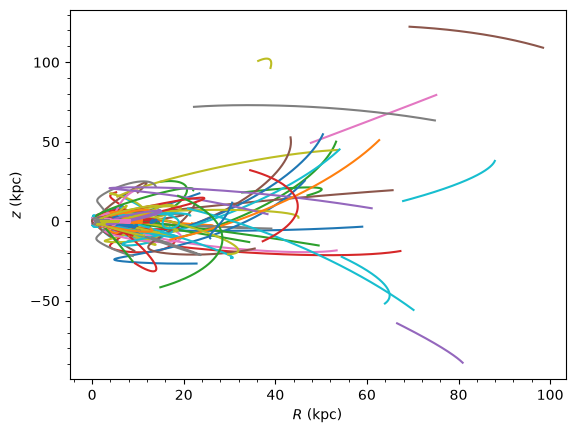

In [10]:
import numpy

ts = numpy.linspace(0.0, 10.0, 10000)
gc.integrate(ts, MWPotential2014)
gc.plot();

## Solar system example with KeplerPotential

Integrate the solar system planets in a Keplerian potential representing the Sun. Because physical outputs are in kpc, we convert them to AU for plotting.

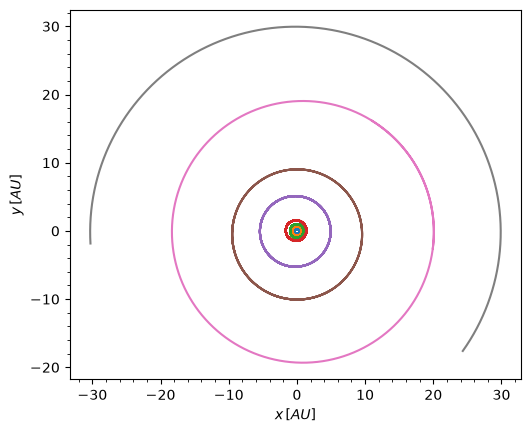

In [11]:
from galpy.potential import KeplerPotential
from galpy.util.conversion import get_physical
from astropy import units as u

ss = Orbit.from_name("solar system")
kp = KeplerPotential(amp=1.0 * u.Msun, **get_physical(ss))
ts = numpy.linspace(0.0, 100.0, 10001) * u.yr
ss.integrate(ts, kp)
kpc_to_au = u.kpc.to(u.AU)
ss.plot(
    d1=f"x*{kpc_to_au}", d2=f"y*{kpc_to_au}", xlabel=r"x\, [AU]", ylabel=r"y\, [AU]"
)
plt.gca().set_aspect("equal");